In [39]:
import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam
from mlxtend.plotting import plot_decision_regions


In [69]:
X,Y= make_moons(n_samples=100,noise=.25)

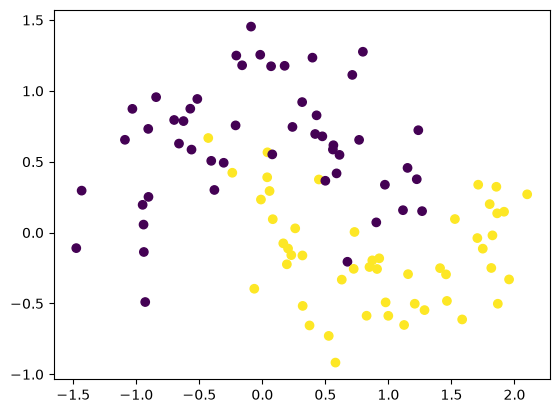

In [70]:
plt.scatter(X[:,0],X[:,1],c=Y)

In [71]:
model = Sequential()
model.add(Dense(128,activation='relu',input_dim=2))
model.add(Dense(128,activation='relu'))
model.add(Dense(1,activation='sigmoid'))
model.summary()

/Users/All file hear/complete ai /Deep learning/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [72]:
adam = Adam(learning_rate=0.01)
model.compile(loss='binary_crossentropy',optimizer=adam,metrics=['accuracy'])
history1 = model.fit(X,Y,validation_split=.2,epochs=2000)

Epoch 1/2000


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.6750 - loss: 0.5906 - val_accuracy: 0.8500 - val_loss: 0.3618
Epoch 2/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8375 - loss: 0.3808 - val_accuracy: 0.9000 - val_loss: 0.2954
Epoch 3/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8625 - loss: 0.3245 - val_accuracy: 0.8500 - val_loss: 0.2573
Epoch 4/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8750 - loss: 0.3114 - val_accuracy: 0.9000 - val_loss: 0.2214
Epoch 5/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8500 - loss: 0.2915 - val_accuracy: 0.9000 - val_loss: 0.1949
Epoch 6/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8875 - loss: 0.2861 - val_accuracy: 0.9000 - val_loss: 0.1813
Epoch 7/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8750 - loss: 0.2793 - val_accuracy: 0.9000 - val_loss: 0.1781
Epoch 8/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8625 - loss: 0.2910 - val_accuracy: 0.9000 - val_loss: 0.18

In [85]:
class basemodel:
    def __init__(self,model):
        self.model = model
    def predict(self,X):
        prediction = self.model.predict(X)
        return (prediction>0.5).astype('int').ravel()
    
model_final =basemodel(model)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 2s 216us/step


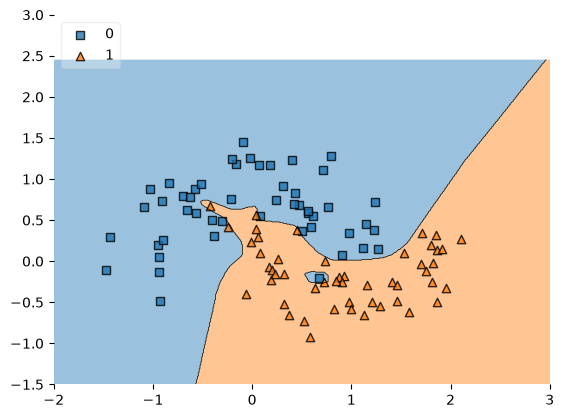

In [86]:
plot_decision_regions(X,Y.astype('int'),clf=model_final,legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,3)
plt.show()


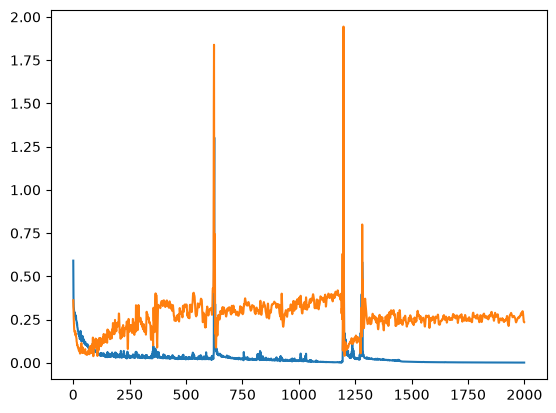

In [75]:
plt.plot(history1.history['loss'],label='train loss')
plt.plot(history1.history['val_loss'],label='val loss')

In [76]:
model2 = Sequential()
model2.add(Dense(128,activation='relu',input_dim=2,kernel_regularizer= tensorflow.keras.regularizers.L2(0.03)))
model2.add(Dense(128,activation='relu',kernel_regularizer=tensorflow.keras.regularizers.L2(0.03)))
model2.add(Dense(1,activation='sigmoid'))
model2.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [77]:
adam = Adam(learning_rate=0.01)
model2.compile(loss='binary_crossentropy',optimizer=adam,metrics=['accuracy'])
history2 = model2.fit(X,Y,validation_split=.2,epochs=2000)

Epoch 1/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.5250 - loss: 4.1096 - val_accuracy: 0.8500 - val_loss: 2.7408
Epoch 2/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8125 - loss: 2.3680 - val_accuracy: 0.8500 - val_loss: 1.5554
Epoch 3/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8250 - loss: 1.3506 - val_accuracy: 0.8500 - val_loss: 0.9350
Epoch 4/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8250 - loss: 0.8448 - val_accuracy: 0.8500 - val_loss: 0.6409
Epoch 5/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8500 - loss: 0.6382 - val_accuracy: 0.8500 - val_loss: 0.5548
Epoch 6/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8500 - loss: 0.5930 - val_accuracy: 0.8500 - val_loss: 0.5476
Epoch 7/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8500 - loss: 0.6049 - val_accuracy: 0.8500 - val_loss: 0.5401
Epoch 8/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8500 - loss: 0.6053 - val_accuracy: 0.8500 - v

In [83]:
class basemodel:
    def __init__(self,model2):
        self.model2 = model2
    def predict(self,X):
        prediction = self.model2.predict(X)
        return (prediction>0.5).astype('int').ravel()
    
model_final2 =basemodel(model2)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 2s 236us/step


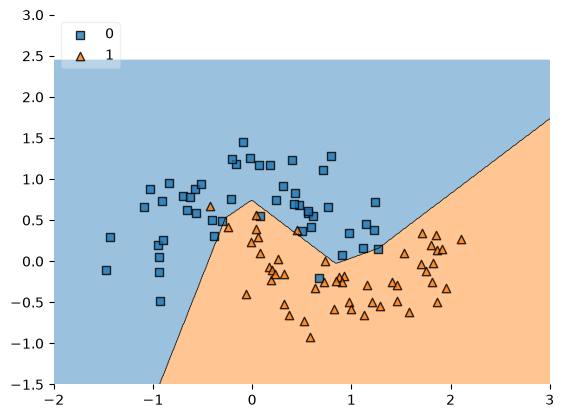

In [87]:
plot_decision_regions(X,Y.astype('int'),clf=model_final2,legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,3)
plt.show()


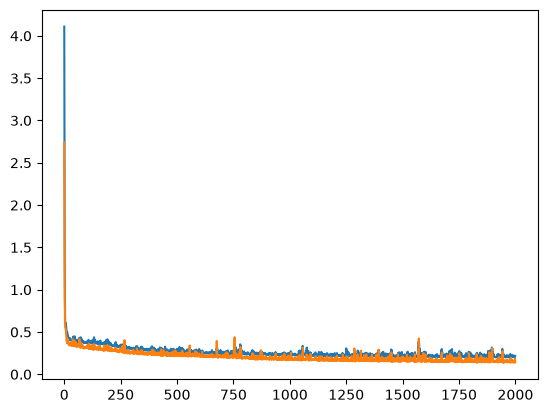

In [80]:
plt.plot(history2.history['loss'],label='train loss')
plt.plot(history2.history['val_loss'],label='val loss')

In [95]:
model1 = model.get_weights()[0].reshape(256)


In [96]:
model2 =model2.get_weights()[0].reshape(256)

In [98]:
import seaborn as sns

<Axes: >

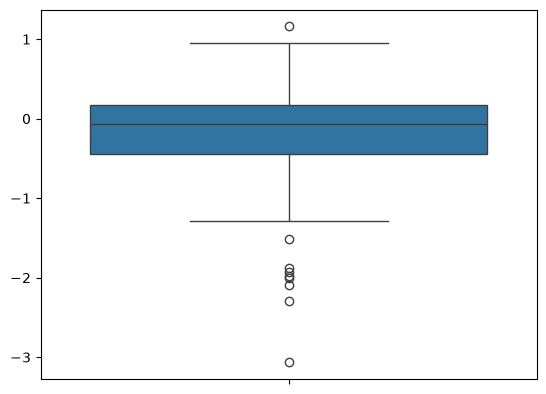

In [105]:
sns.boxplot(data=model1)

<Axes: >

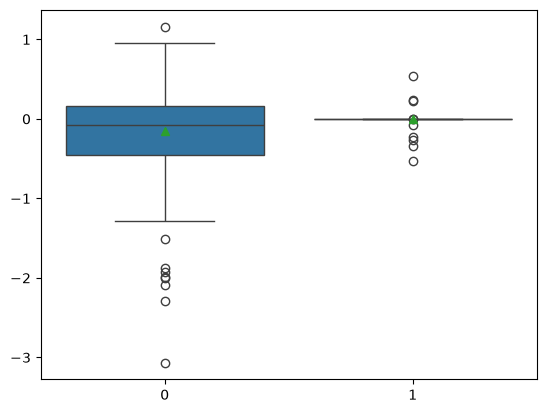

In [106]:
sns.boxplot(data=[model1,model2],showmeans=True)

In [109]:
print(model1.max())
print(model2.max())

1.1612906
0.54573005


In [110]:
print(model1.min())
print(model2.min())

-3.0652096
-0.53429943


/var/folders/83/vkcpj0h51_1gwqn9b___8hh00000gn/T/ipykernel_56747/3744633099.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(model1)
/var/folders/83/vkcpj0h51_1gwqn9b___8hh00000gn/T/ipykernel_56747/3744633099.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(model2)


<Axes: ylabel='Density'>

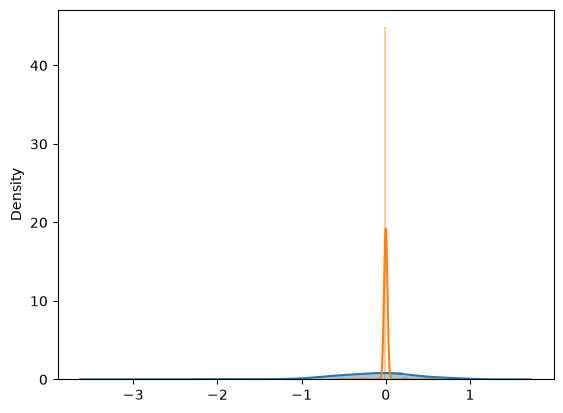

In [114]:
sns.distplot(model1)
sns.distplot(model2)

/var/folders/83/vkcpj0h51_1gwqn9b___8hh00000gn/T/ipykernel_56747/592308780.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(model1)


<Axes: ylabel='Density'>

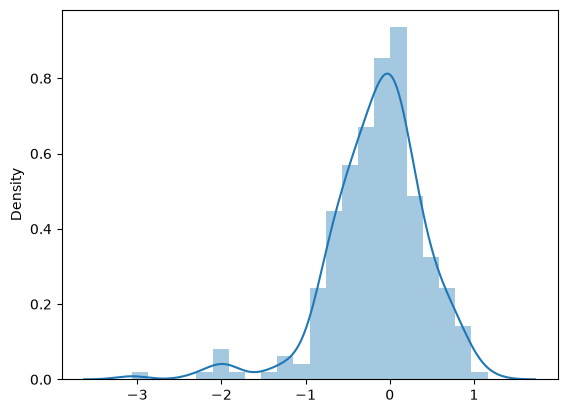

In [117]:
sns.distplot(model1)

/var/folders/83/vkcpj0h51_1gwqn9b___8hh00000gn/T/ipykernel_56747/4195786622.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(model2)


<Axes: ylabel='Density'>

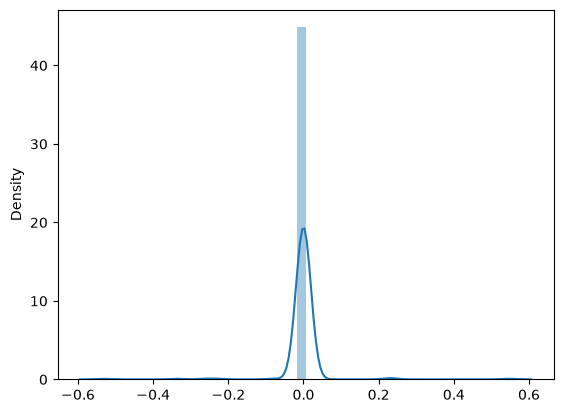

In [118]:
sns.distplot(model2)